In [1]:
import torch
from torch import eye, ones
from torch.distributions import MultivariateNormal

from sbi.analysis.plot import sbc_rank_plot
from sbi.diagnostics import check_sbc, check_tarp, run_sbc, run_tarp
from sbi.inference import NPE

# Set random seed
_ = torch.manual_seed(42)

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [ ]:
num_dim = 2 # 2d gaussian
num_simulations = 10_000    # no of training pairs we generate

prior_mean = ones(num_dim)      #mean vector [1,1]
prior_cov = 2 * eye(num_dim)       # cov of 2* identity matrix
prior = MultivariateNormal(
    loc=prior_mean, covariance_matrix=prior_cov, validate_args=False
)

In [3]:
default_likelihood_loc = 0.0  # let's start with 0 shift
default_likelihood_scale = 0.01  # let's smear theta only by a little bit


def simulator(theta, loc=default_likelihood_loc, scale=default_likelihood_scale):
    """linear gaussian inspired by sbibm
    https://github.com/sbi-benchmark/sbibm/blob/15f068a08a938383116ffd92b92de50c580810a3/sbibm/tasks/gaussian_linear/task.py#L74
    """
    num_dim = theta.shape[-1]
    cov_ = scale * eye(num_dim)  # always positively semi-definite

    # using validate_args=False disables sanity checks on `covariance_matrix`
    # for the sake of speed
    value = MultivariateNormal(
        loc=(theta + loc), covariance_matrix=cov_, validate_args=False
    ).sample()
    return value

theta = prior.sample((num_simulations,))
x = simulator(theta)

In [4]:
theta_o = prior.sample((1,))
x_o = simulator(theta_o)
print("theta:", theta_o.numpy())
print("x    :", x_o.numpy())

theta: [[3.8389134 1.6634762]]
x    : [[3.9267206 1.6138272]]


In [ ]:
# we use a mdn model to have a fast turnaround with training the NPE
inferer = NPE(prior, density_estimator="nsf")
# append simulations and run training.
inferer.append_simulations(theta, x).train(training_batch_size=200)

 Neural network successfully converged after 61 epochs.

In [ ]:
posterior = inferer.build_posterior()
posterior_samples = posterior.sample((10_000,), x=x_o)

# Generate predictive samples by simulating from posterior samples.
posterior_predictive_samples = simulator(posterior_samples)

  0%|          | 0/10000 [00:00<?, ?it/s]

c:\Users\vasir\Documents\0 Research Project\.venv\Lib\site-packages\nflows\transforms\lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\BatchLinearAlgebra.cpp:2196.)
  outputs, _ = torch.triangular_solve(


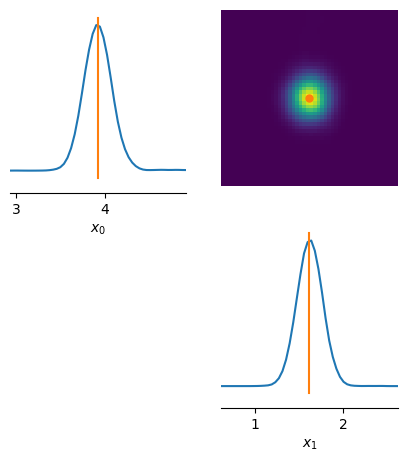

In [7]:
# let's do some posterior predictive checks to see if the
# posterior predictive samples cluster aournd the observation `x_o`.
from sbi.analysis import pairplot

fig, ax = pairplot(
    samples=posterior_predictive_samples,
    points=x_o,
    limits=list(zip(x_o.flatten() - 1.0, x_o.flatten() + 1.0, strict=False)),
    upper="kde",
    diag="kde",
    figsize=(5, 5),
    labels=[rf"$x_{d}$" for d in range(3)],
)